## Notebook 02
---
### Machine Learning
---
#### Prerequisites
- Python
- NumPy
- Pandas
- Scikit-learn

In [2]:
from __future__ import annotations

import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

##### Supervised Learning: Regression

In [3]:
# data cleaning
fifa = pd.read_csv("../data/fifa23_raw.csv")

fifa.head(5)

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Real Face,Position,Joined,Loaned From,Contract Valid Until,Height,Weight,Release Clause,Kit Number,Best Overall Rating
0,209658,L. Goretzka,27,https://cdn.sofifa.net/players/209/658/23_60.png,Germany,https://cdn.sofifa.net/flags/de.png,87,88,FC Bayern München,https://cdn.sofifa.net/teams/21/30.png,...,Yes,"<span class=""pos pos28"">SUB","Jul 1, 2018",NaN,2026,189cm,82kg,€157M,8.0,NaN
1,212198,Bruno Fernandes,27,https://cdn.sofifa.net/players/212/198/23_60.png,Portugal,https://cdn.sofifa.net/flags/pt.png,86,87,Manchester United,https://cdn.sofifa.net/teams/11/30.png,...,Yes,"<span class=""pos pos15"">LCM","Jan 30, 2020",NaN,2026,179cm,69kg,€155M,8.0,NaN
2,224334,M. Acuña,30,https://cdn.sofifa.net/players/224/334/23_60.png,Argentina,https://cdn.sofifa.net/flags/ar.png,85,85,Sevilla FC,https://cdn.sofifa.net/teams/481/30.png,...,No,"<span class=""pos pos7"">LB","Sep 14, 2020",NaN,2024,172cm,69kg,€97.7M,19.0,NaN
3,192985,K. De Bruyne,31,https://cdn.sofifa.net/players/192/985/23_60.png,Belgium,https://cdn.sofifa.net/flags/be.png,91,91,Manchester City,https://cdn.sofifa.net/teams/10/30.png,...,Yes,"<span class=""pos pos13"">RCM","Aug 30, 2015",NaN,2025,181cm,70kg,€198.9M,17.0,NaN
4,224232,N. Barella,25,https://cdn.sofifa.net/players/224/232/23_60.png,Italy,https://cdn.sofifa.net/flags/it.png,86,89,Inter,https://cdn.sofifa.net/teams/44/30.png,...,Yes,"<span class=""pos pos13"">RCM","Sep 1, 2020",NaN,2026,172cm,68kg,€154.4M,23.0,NaN


In [4]:
fifa = fifa.drop(columns=["Photo", "Flag", "Club Logo", "Best Overall Rating"])

fifa.head(5)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Special,...,Body Type,Real Face,Position,Joined,Loaned From,Contract Valid Until,Height,Weight,Release Clause,Kit Number
0,209658,L. Goretzka,27,Germany,87,88,FC Bayern München,€91M,€115K,2312,...,Unique,Yes,"<span class=""pos pos28"">SUB","Jul 1, 2018",NaN,2026,189cm,82kg,€157M,8.0
1,212198,Bruno Fernandes,27,Portugal,86,87,Manchester United,€78.5M,€190K,2305,...,Unique,Yes,"<span class=""pos pos15"">LCM","Jan 30, 2020",NaN,2026,179cm,69kg,€155M,8.0
2,224334,M. Acuña,30,Argentina,85,85,Sevilla FC,€46.5M,€46K,2303,...,Stocky (170-185),No,"<span class=""pos pos7"">LB","Sep 14, 2020",NaN,2024,172cm,69kg,€97.7M,19.0
3,192985,K. De Bruyne,31,Belgium,91,91,Manchester City,€107.5M,€350K,2303,...,Unique,Yes,"<span class=""pos pos13"">RCM","Aug 30, 2015",NaN,2025,181cm,70kg,€198.9M,17.0
4,224232,N. Barella,25,Italy,86,89,Inter,€89.5M,€110K,2296,...,Normal (170-),Yes,"<span class=""pos pos13"">RCM","Sep 1, 2020",NaN,2026,172cm,68kg,€154.4M,23.0


In [5]:
def split_work_rate(series: pd.Series) -> tuple[pd.Series, pd.Series]:
    """
    Split ``'High/Medium'`` into two ordered categoricals.

    :param series: The raw ``Work Rate`` column.
    :return: ``(attacking, defensive)`` over Low < Medium < High
    """
    valid = series.where(~series.str.contains("N/A", na=False))
    parts = valid.str.split("/", expand=True)
    order = pd.CategoricalDtype(categories=["Low", "Medium", "High"], ordered=True)

    return parts[0].str.strip().astype(order), parts[1].str.strip().astype(order)

def clean_name(series: pd.Series) -> tuple[pd.Series, pd.Series]:
    """
    Split a numeric prefix out of a player name.

    :param series: The raw ``Name`` column.
    :return: ``(name, squad_number)``
    """
    normalized = series.str.replace("\u00a0", " ", regex=False).str.strip()
    squad_number = pd.to_numeric(normalized.str.extract(r"^(\d+)\s", expand=False), errors="coerce").astype("Int16")
    name = normalized.str.replace(r"^\d+\s+", "", regex=True).str.strip()

    return name, squad_number

def parse_money(series: pd.Series) -> pd.Series:
    """
    Parse euro strings into floats.

    :param series: Strings of euro values
    :return: Plain euro amounts, ``Nan`` where parsing failed
    """
    parts = series.str.extract(r"^€?([\d.]+)\s*([KM]?)$")
    amount = pd.to_numeric(parts[0], errors="coerce")
    multiplier = parts[1].map({"K": 1_000.0, "M": 1_000_000.0}).fillna(1.0)

    return amount * multiplier

def parse_measurement(series: pd.Series, unit: str) -> pd.Series:
    """
    Strip a unit suffix and convert to a number.

    :param series: Strings measurements
    :param unit: The suffix to remove
    :return: A float Series, ``NaN`` where parsing failed.
    """
    return pd.to_numeric(series.str.removesuffix(unit).str.strip(), errors="coerce")

In [6]:
attack_rate, defence_rate = split_work_rate(fifa["Work Rate"])
player_name, squad_number = clean_name(fifa["Name"])

body = fifa["Body Type"].str.extract(r"^(?P<build>\w+)(?:\s*\((?P<band>[^)]+)\))?")
bare_year = fifa["Contract Valid Until"].str.fullmatch(r"\d{4}").fillna(False)
real_date = ~bare_year & fifa["Contract Valid Until"].notna()
contract_date = pd.Series(pd.NaT, index=fifa.index, dtype="datetime64[us]")
contract_date[real_date] = pd.to_datetime(fifa.loc[real_date, "Contract Valid Until"], format="%b %d, %Y", errors="coerce")

fifa = fifa.assign(
    name=player_name,
    squad_number=squad_number,
    value_eur=parse_money(fifa["Value"]),
    wage_eur=parse_money(fifa["Wage"]),
    release_clause_eur=parse_money(fifa["Release Clause"]),
    height_cm=parse_measurement(fifa["Height"], "cm"),
    weight_kg=parse_measurement(fifa["Weight"], "kg"),
    position=fifa["Position"].str.extract(r">([A-Z]+)$", expand=False).astype("category"),
    loan_club=fifa["Loaned From"].str.extract(r">([^<]+)</a>", expand=False),
    work_rate_attack=attack_rate,
    work_rate_defence=defence_rate,
    build=body["build"].astype("category"),
    height_band=body["band"].astype("category"),
    joined_date=pd.to_datetime(fifa["Joined"], format="%b %d, %Y", errors="coerce"),
    contract_end_year=pd.to_numeric(fifa["Contract Valid Until"].str.extract(r"(\d{4})$", expand=False), errors="coerce").astype("Int16"),
    contract_end_date=contract_date,
    is_on_loan=fifa["Loaned From"].notna(),
    is_free_agent=fifa["Club"].isna(),
    has_release_clause=fifa["Release Clause"].notna()
)

fifa = fifa.assign(
    bmi=pd.col("weight_kg") / (pd.col("height_cm") / 100) ** 2,
    growth_potential=pd.col("Potential") - pd.col("Overall"),
    wage_to_value=pd.col("wage_eur") / pd.col("value_eur").replace(0.0, np.nan),
    years_at_club=(pd.Timestamp("2023-01-01") - pd.col("joined_date")).dt.days / 365.25
)

counts = fifa["Nationality"].value_counts()
frequent = counts[counts >= 20].index

fifa["nationality_grouped"] = fifa["Nationality"].where(fifa["Nationality"].isin(frequent), "Other").astype("category")

fifa = fifa.drop(columns=["Name", "Value", "Wage", "Release Clause", "Height", "Weight", "Position", "Work Rate", "Body Type", "Joined", "Contract Valid Until", "Loaned From"])

fifa.head(5)

,ID,Age,Nationality,Overall,Potential,Club,Special,Preferred Foot,International Reputation,Weak Foot,...,contract_end_year,contract_end_date,is_on_loan,is_free_agent,has_release_clause,bmi,growth_potential,wage_to_value,years_at_club,nationality_grouped
0,209658,27,Germany,87,88,FC Bayern München,2312,Right,4.0,4.0,...,2026,NaT,False,False,True,22.955684,1,0.001264,4.503765,Germany
1,212198,27,Portugal,86,87,Manchester United,2305,Right,3.0,3.0,...,2026,NaT,False,False,True,21.534908,1,0.002420,2.921287,Portugal
2,224334,30,Argentina,85,85,Sevilla FC,2303,Left,2.0,3.0,...,2024,NaT,False,False,True,23.323418,0,0.000989,2.297057,Argentina
3,192985,31,Belgium,91,91,Manchester City,2303,Right,4.0,5.0,...,2025,NaT,False,False,True,21.366869,0,0.003256,7.340178,Belgium
4,224232,25,Italy,86,89,Inter,2296,Right,3.0,3.0,...,2026,NaT,False,False,True,22.985398,3,0.001229,2.332649,Italy


In [7]:
# after cleaning fifa data
players = fifa[fifa["value_eur"] > 0]

features = ["Overall", "Potential", "Age"]
X = players[features]
y = np.log10(players["value_eur"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"There are {len(X_train):,} training players, and {len(X_test):,} test players.")

There are 13,901 training players, and 3,476 test players.


In [8]:
# A baseline predicts the training mean for everyone.
baseline_r2 = r2_score(y_test, np.full(len(y_test), y_train.mean()))

# Fitting, prediction and evaluation.
regression = LinearRegression().fit(X_train, y_train)
predicted = regression.predict(X_test)

model_r2 = r2_score(y_test, predicted)
typical_factor = 10 ** mean_absolute_error(y_test, predicted)

print("R² share of the variation (1.0 is perfect, 0.0 is the baseline)\n")
print(f"baseline (predict the mean): {baseline_r2:6.3f}")
print(f"linear regression: {model_r2:6.3f}")
print(f"typical error: The prediction is within a factor of {typical_factor:.2f} of the true value.")

R² share of the variation (1.0 is perfect, 0.0 is the baseline)

baseline (predict the mean): -0.001
linear regression:  0.961
typical error: The prediction is within a factor of 1.21 of the true value.


In [9]:
# Learning and Interpretation
for name, coefficient in zip(features, regression.coef_, strict=True):
    print(f"{coefficient:+.4f} x {name:<10} -> each extra point multiplies value by {10 ** coefficient:.3f}")

per_point = 10 ** regression.coef_[features.index("Overall")]
per_year = 10 ** regression.coef_[features.index("Age")]

print(f"\nOne extra rating point is worth {per_point - 1:+.0%} in value.")
print(f"One extra year of age, holding rating fixed, is worth {per_year - 1:+.0%}.")

+0.0850 x Overall    -> each extra point multiplies value by 1.216
+0.0004 x Potential  -> each extra point multiplies value by 1.001
-0.0488 x Age        -> each extra point multiplies value by 0.894

One extra rating point is worth +22% in value.
One extra year of age, holding rating fixed, is worth -11%.


Points on the dashed line are perfect. The scatter around it is the error.
It is roughly the same width at 50k as at 50M euros.


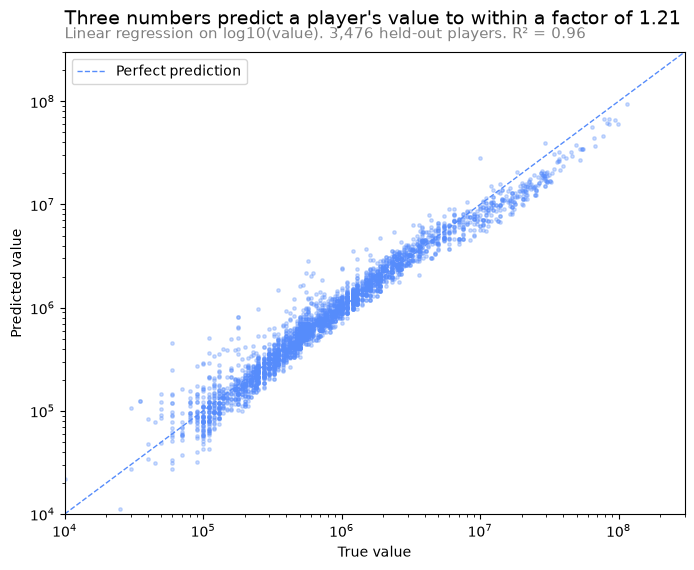

In [10]:
# visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))

main_title = f"Three numbers predict a player's value to within a factor of {typical_factor:.2f}"
subtitle = f"Linear regression on log10(value). {len(X_test):,} held-out players. R² = {model_r2:.2f}"

ax.scatter(10 ** y_test, 10 ** predicted, s=6, alpha=0.3)
limits = (1e4, 3e8)

ax.set_title(main_title, fontsize=14, pad=20, loc="left")
ax.text(0.0, 1.03, subtitle, fontsize=11, color="gray", transform=ax.transAxes, ha="left")

ax.plot(limits, limits, linewidth=1, linestyle="--", label="Perfect prediction")
ax.set(xscale="log", yscale="log", xlim=limits, ylim=limits, xlabel="True value", ylabel="Predicted value")
ax.legend(loc="upper left")

print("Points on the dashed line are perfect. The scatter around it is the error.")
print("It is roughly the same width at 50k as at 50M euros.")

##### Supervised Learning: Classification

In [11]:
# cleaning data
bnpl = pd.read_csv("../data/bnpl_default_risk.csv")

low: int = 300
high: int = 850

out_of_range = ~bnpl["Credit_Score"].between(low, high) & bnpl["Credit_Score"].notna()
bnpl.loc[out_of_range, "Credit_Score"] = np.nan

bnpl = bnpl.assign(
    income_missing=bnpl["Income_USD"].isna(),
    credit_score_missing=bnpl["Credit_Score"].isna(),
    has_late_payments=bnpl["Late_Payment_History"].astype("str").eq("Yes"),
    debt_to_income=bnpl["Total_BNPL_Debt_USD"] / bnpl["Income_USD"].replace(0.0, np.nan),
    debt_per_loan=(bnpl["Total_BNPL_Debt_USD"] / bnpl["Total_BNPL_Active_Loans"].replace(0, np.nan)).fillna(0.0)
).drop(columns=["Late_Payment_History"])

In [12]:
features = ["Age", "Income_USD", "Credit_Score", "Total_BNPL_Active_Loans", "Total_BNPL_Debt_USD", "Average_Transaction_Value_USD", "has_late_payments"]

X = bnpl[features].astype(float)
y = (bnpl["Default_Risk"] == "High").astype(int)

print(f"There are {len(X):,} customers, {y.mean():.1%} are high-risk.")

There are 10,000 customers, 5.2% are high-risk.


In [13]:
print("Missing values per feature: ")
print(f"{X.isna().sum().to_string()}")

Missing values per feature: 
Age                                0
Income_USD                       305
Credit_Score                     298
Total_BNPL_Active_Loans            0
Total_BNPL_Debt_USD                0
Average_Transaction_Value_USD      0
has_late_payments                  0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baseline_predictions = baseline.predict(X_test)

print(f"Baseline accuracy: {accuracy_score(y_test, baseline_predictions):.1%}")
print(f"Baseline balanced accuracy: {balanced_accuracy_score(y_test, baseline_predictions):.3f}")
print(f"High-risk customers caught: {baseline_predictions.sum()}")

Baseline accuracy: 94.8%
Baseline balanced accuracy: 0.500
High-risk customers caught: 0


In [15]:
classifier = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=1_000)
)

classifier.fit(X_train, y_train)
predictions = classifier.predict(X_test)

In [16]:
(tn, fp), (fn, tp) = confusion_matrix(y_test, predictions)
print("              Predicted not    Predicted high")
print(f"Actually not  {tn:>10,} {fp:>12,}")
print(f"Actually high {fn:>10,} {tp:>12,}")

              Predicted not    Predicted high
Actually not       1,891            5
Actually high         18           86


In [17]:
print(f"Accuracy: {accuracy_score(y_test, predictions):.1%}")
print(f"Recall:   {tp / (tp + fn):.1%}  ({tp} of {tp + fn} high-risk customers caught.)")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, predictions):.3f}")

Accuracy: 98.9%
Recall:   82.7%  (86 of 104 high-risk customers caught.)
Balanced accuracy: 0.912


##### Unsupervised Learning: Clustering

In [18]:
segment_features = ["Age", "Overall", "Potential", "value_eur", "wage_eur"]

segments = players[segment_features].assign(
    value_eur=np.log10(players["value_eur"]),
    wage_eur=np.log10(players["wage_eur"].clip(lower=100))
)

scaled = StandardScaler().fit_transform(segments)

In [19]:
K = 4

kmeans = KMeans(n_clusters=K, n_init=10, random_state=0).fit(scaled)
segments = segments.assign(cluster=kmeans.labels_)

profile = segments.groupby("cluster").mean()
profile["players"] = segments["cluster"].value_counts().sort_index()
profile["value_eur"] = 10 ** profile["value_eur"]
profile["wage_eur"] = 10 ** profile["wage_eur"]

print(profile.to_string(float_format=lambda v: f"{v:,.1f}"))

         Age  Overall  Potential   value_eur  wage_eur  players
cluster                                                        
0       20.7     63.1       73.8   997,504.9   1,626.8     5651
1       26.4     75.2       78.6 6,626,294.3  23,037.4     3377
2       20.1     54.7       65.6   228,571.1     787.4     5321
3       28.9     65.5       66.4   602,192.1   1,982.7     3028


In [20]:
names = {profile["Overall"].idxmax(): "Established stars"}
names.setdefault(profile["Age"].idxmax(), "Veterans")

remaining = profile.drop(list(names)).sort_values("Overall", ascending=False).index

for cluster, label in zip(remaining, ["Rising prospects", "Development players", "Others"], strict=False):
    names[cluster] = label

segments["segment"] = segments["cluster"].map(names)

profile["headroom"] = profile["Potential"] - profile["Overall"]     # how much better they may get

for cluster, row in profile.iterrows():
    print(f"Cluster {cluster}: {names[cluster]:<20} n={row["players"]:>6,.0f}    Age: {row["Age"]:.0f}    Overall: {row["Overall"]:.0f}    Headroom: {row["headroom"]:+.0f}    Value: €{row["value_eur"] / 1e6:.1f}M")

Cluster 0: Rising prospects     n= 5,651    Age: 21    Overall: 63    Headroom: +11    Value: €1.0M
Cluster 1: Established stars    n= 3,377    Age: 26    Overall: 75    Headroom: +3    Value: €6.6M
Cluster 2: Development players  n= 5,321    Age: 20    Overall: 55    Headroom: +11    Value: €0.2M
Cluster 3: Veterans             n= 3,028    Age: 29    Overall: 65    Headroom: +1    Value: €0.6M


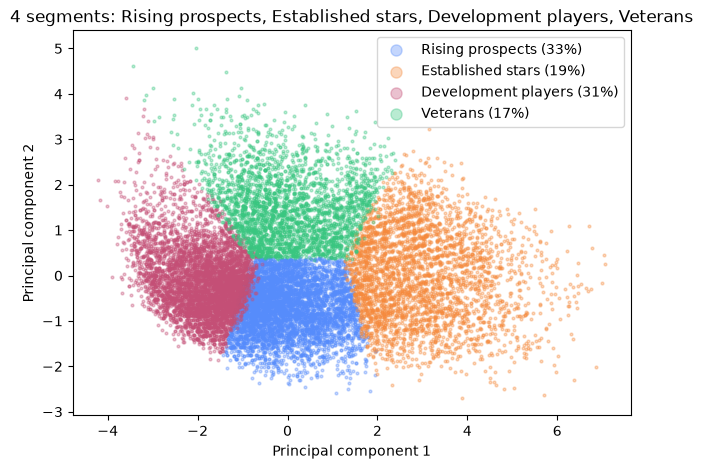

In [21]:
projection = PCA(n_components=2).fit_transform(scaled)

fig, ax = plt.subplots(figsize=(7.2,5))

main_title = f"{K} segments: " + ", ".join(names[cluster] for cluster in range(K))

for cluster in range(K):
    mask = segments["cluster"] == cluster

    ax.scatter(projection[mask, 0], projection[mask, 1], s=4, alpha=0.35, label=f"{names[cluster]} ({mask.mean():.0%})")

ax.set_title(main_title)
ax.set(xlabel="Principal component 1", ylabel="Principal component 2")
ax.legend(markerscale=4)

##### Deep Learning

In [24]:
# Gradient descent
overall = players["Overall"].to_numpy(dtype=np.float64)

x = (overall - overall.mean()) / overall.std()
y = np.log10(players["value_eur"].to_numpy())

w, b = 0.0, 0.0
learning_rate = 0.1
history = []

for _ in range(60):
    prediction = w * x + b
    loss = np.mean((prediction - y) ** 2)

    grad_w = np.mean(2 * (prediction - y) * x)
    grad_b = np.mean(2 * (prediction - y))

    w -= learning_rate * grad_w
    b -= learning_rate * grad_b

    history.append(loss)

# The exact least-squares results for comparison
w_exact = np.cov(x, y, bias=True)[0, 1] / x.var()
b_exact = y.mean() - w_exact * x.mean()

print(f"Gradient descent after {len(history)} steps: w = {w:.4f}  b = {b:.4f}  loss = {history[-1]:.4f}")
print(f"Exact least-squares results: w = {w_exact:.4f}  b = {b_exact:.4f}")

Gradient descent after 60 steps: w = 0.5514  b = 5.9246  loss = 0.0476
Exact least-squares results: w = 0.5514  b = 5.9246


[Text(0.5, 0, 'step'), Text(0, 0.5, 'loss')]

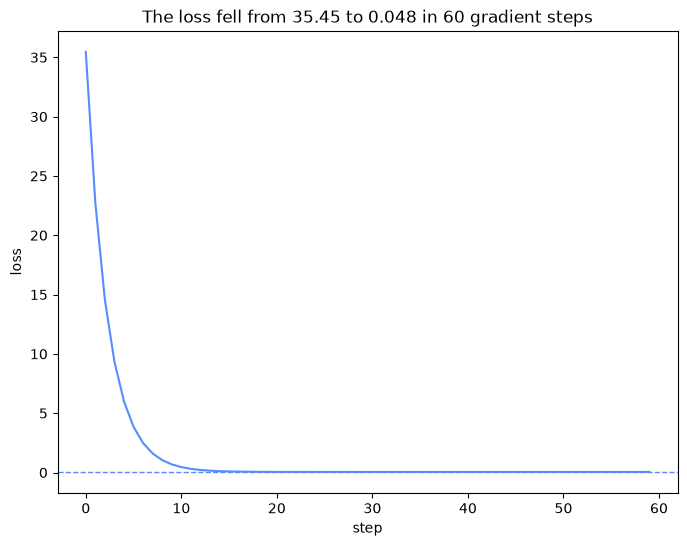

In [28]:
fig, ax = plt.subplots(figsize=(8,6))

main_title = f"The loss fell from {history[0]:.2f} to {history[-1]:.3f} in {len(history)} gradient steps"

ax.set_title(main_title)

ax.plot(history)
ax.axhline(history[-1], linestyle="--", linewidth=1)
ax.set(xlabel="step", ylabel="loss")